# 05 Final Modelling Analysis

This notebook estimates adjusted associations for:

1. Length of stay.
2. Total inpatient costs.
3. High-cost admission status.

## Final model strategy

The final report should use:

1. **Negative Binomial GLM** for length of stay, because the baseline Poisson LOS model showed overdispersion.
2. **Gamma GLM with log link** for total inpatient costs, because cost data are positive, continuous and right-skewed.
3. **Logistic GLM** for high-cost admission status, because the outcome is binary.



In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from matplotlib.ticker import FuncFormatter, FixedLocator, NullFormatter
from pathlib import Path
import statsmodels.api as sm
import warnings

warnings.filterwarnings("ignore")

pd.set_option("display.max_columns", 120)
pd.set_option("display.max_rows", 120)

# Detect project directory whether notebook is run from root folder or /notebooks
current_dir = Path.cwd()

if current_dir.name == "notebooks":
    project_dir = current_dir.parent
else:
    project_dir = current_dir

data_processed = project_dir / "data" / "processed"
outputs_tables = project_dir / "outputs" / "tables"
outputs_figures = project_dir / "outputs" / "figures"

for folder in [data_processed, outputs_tables, outputs_figures]:
    folder.mkdir(parents=True, exist_ok=True)

print("Current directory:", current_dir)
print("Project directory:", project_dir)
print("Processed data folder:", data_processed)
print("Tables output folder:", outputs_tables)
print("Figures output folder:", outputs_figures)


Current directory: /Users/marissa/Desktop/portfolio/oncology-health-economics-portfolio/project_01_sparcs_cancer_utilisation_cost/notebooks
Project directory: /Users/marissa/Desktop/portfolio/oncology-health-economics-portfolio/project_01_sparcs_cancer_utilisation_cost
Processed data folder: /Users/marissa/Desktop/portfolio/oncology-health-economics-portfolio/project_01_sparcs_cancer_utilisation_cost/data/processed
Tables output folder: /Users/marissa/Desktop/portfolio/oncology-health-economics-portfolio/project_01_sparcs_cancer_utilisation_cost/outputs/tables
Figures output folder: /Users/marissa/Desktop/portfolio/oncology-health-economics-portfolio/project_01_sparcs_cancer_utilisation_cost/outputs/figures


## 1. Helper functions

These functions format model outputs and figures consistently.


In [2]:
def money_formatter(x, pos):
    if abs(x) >= 1_000_000:
        return f"${x/1_000_000:.1f}M"
    if abs(x) >= 1_000:
        return f"${x/1_000:.0f}K"
    return f"${x:.0f}"

def plain_ratio_formatter(x, pos):
    """Format log-scaled ratio axis ticks as plain numbers, not scientific notation."""
    if x <= 0:
        return ""
    if x < 1:
        return f"{x:.1f}"
    if x < 10:
        return f"{x:.1f}".rstrip("0").rstrip(".") if x % 1 else f"{x:.1f}"
    return f"{x:.0f}"

def apply_clean_log_ratio_ticks(ax, tick_values=None):
    """Apply fixed log-scale ticks with plain-number labels.

    This prevents matplotlib from showing labels such as 2 × 10⁰.
    """
    if tick_values is None:
        tick_values = [0.3, 0.5, 0.6, 0.8, 1.0, 1.2, 1.5, 2.0, 3.0, 5.0, 10.0]

    xmin, xmax = ax.get_xlim()
    visible_ticks = [tick for tick in tick_values if xmin <= tick <= xmax]

    # Always include 1.0 when visible because it is the no-association reference.
    if xmin <= 1.0 <= xmax and 1.0 not in visible_ticks:
        visible_ticks.append(1.0)

    visible_ticks = sorted(set(visible_ticks))

    if len(visible_ticks) > 0:
        ax.xaxis.set_major_locator(FixedLocator(visible_ticks))
        ax.xaxis.set_major_formatter(FuncFormatter(plain_ratio_formatter))
        ax.xaxis.set_minor_formatter(NullFormatter())

def save_current_figure(filename):
    fig_path = outputs_figures / filename
    plt.savefig(fig_path, dpi=300, bbox_inches="tight")
    plt.show()
    print("Saved:", fig_path)

def make_model_table(result, model_name, effect_type="coefficient", exponentiate=False):
    """Create a tidy model results table from a statsmodels result object."""
    params = result.params
    conf = result.conf_int()
    pvalues = result.pvalues
    bse = result.bse

    table = pd.DataFrame({
        "model_name": model_name,
        "term": params.index,
        "coefficient": params.values,
        "std_error": bse.values,
        "ci_lower": conf.iloc[:, 0].values,
        "ci_upper": conf.iloc[:, 1].values,
        "p_value": pvalues.values
    })

    if exponentiate:
        table[effect_type] = np.exp(table["coefficient"])
        table[f"{effect_type}_ci_lower"] = np.exp(table["ci_lower"])
        table[f"{effect_type}_ci_upper"] = np.exp(table["ci_upper"])

    table["p_value"] = table["p_value"].round(4)

    numeric_cols = table.select_dtypes(include=[np.number]).columns
    table[numeric_cols] = table[numeric_cols].round(4)

    return table

def add_constant_and_fit_columns(data, covariates):
    X = data[covariates].copy()
    X = X.apply(pd.to_numeric, errors="coerce")
    X = sm.add_constant(X, has_constant="add")
    return X

def write_model_failure(model_name, error):
    return pd.DataFrame({
        "model_name": [model_name],
        "status": ["failed"],
        "message": [str(error)]
    })

term_label_map = {
    "severity_score": "Severity score",
    "is_emergency_admission_int": "Emergency admission",
    "older_adult_70plus": "Age 70 or older",
    "haematologic_cancer": "Haematologic cancer"
}

def plot_ratio_model(
    model_table,
    ratio_col,
    lower_col,
    upper_col,
    title,
    xlabel,
    filename,
    log_scale=True,
    tick_values=None
):
    """Plot exponentiated model ratios excluding intercept.

    Used for IRRs, cost ratios and odds ratios. When log_scale=True,
    the x-axis is formatted with plain-number tick labels for report readability.
    """
    plot_data = model_table[model_table["term"] != "const"].copy()

    if plot_data.empty:
        print("No non-intercept terms to plot.")
        return

    plot_data["term_label"] = plot_data["term"].map(term_label_map).fillna(plot_data["term"])
    plot_data = plot_data.sort_values(ratio_col)

    y_positions = np.arange(len(plot_data))
    x = plot_data[ratio_col].values
    xerr = np.vstack([
        x - plot_data[lower_col].values,
        plot_data[upper_col].values - x
    ])

    fig, ax = plt.subplots(figsize=(8, 5))
    ax.errorbar(x, y_positions, xerr=xerr, fmt="o", capsize=4)
    ax.axvline(1, linestyle="--", linewidth=1)

    ax.set_yticks(y_positions)
    ax.set_yticklabels(plot_data["term_label"])
    ax.set_xlabel(xlabel)
    ax.set_title(title)

    if log_scale:
        ax.set_xscale("log")
        apply_clean_log_ratio_ticks(ax, tick_values=tick_values)

    plt.tight_layout()
    save_current_figure(filename)


## 2. Load model input dataset

The main modelling dataset is the strict primary cancer cohort with valid length of stay, total charges and total costs.

This notebook uses the `sparcs_2024_model_input.csv` file produced in Notebook 02.


In [3]:
model_input_path = data_processed / "sparcs_2024_model_input.csv"

if not model_input_path.exists():
    raise FileNotFoundError(
        "Missing data/processed/sparcs_2024_model_input.csv. "
        "Rerun Notebook 02 before continuing."
    )

model_df = pd.read_csv(model_input_path, low_memory=False)

print("Model input shape:", model_df.shape)
display(model_df.head())


Model input shape: (1218, 49)


,discharge_year,health_service_area,hospital_county,facility_name,permanent_facility_id,zip_code,age_group,gender,race,ethnicity,type_of_admission,patient_disposition,emergency_department_indicator,emergency_department_flag,is_emergency_admission,discharged_home_flag,length_of_stay_raw,length_of_stay_clean,length_of_stay_topcoded,length_of_stay_invalid,ccsr_diagnosis_code,ccsr_diagnosis_code_clean,ccsr_diagnosis_description,cancer_cohort_type,is_primary_cancer_admission,is_broader_cancer_related_admission,is_excluded_cancer_keyword_match,cancer_category,cancer_group,apr_drg_code,apr_drg_description,apr_mdc_code,apr_mdc_description,apr_severity_of_illness_code,apr_severity_of_illness,apr_risk_of_mortality,apr_medical_surgical,ccsr_procedure_code,ccsr_procedure_description,payment_typology_1,primary_payer,payment_typology_2,payment_typology_3,total_charges,total_charges_clean,log_total_charges_clean,total_costs,total_costs_clean,log_total_costs_clean
0,2024,New York City,New York,NEW YORK-PRESBYTERIAN HOSPITAL - NEW YORK WEIL...,1458.0,103,18-29,M,White,Not Span/Hispanic,Emergency,Home or Self Care,Y,1,1,1,2,2,False,False,NEO057,NEO057,HODGKIN LYMPHOMA,primary_cancer,1,1,0,HODGKIN LYMPHOMA,lymphoma,691,"LYMPHOMA, MYELOMA AND NON-ACUTE LEUKEMIA",17,"LYMPHATIC, HEMATOPOIETIC, OTHER MALIGNANCIES, ...",1,Minor,Minor,Medical,IMG008,ULTRASONOGRAPHY,Medicaid,Medicaid,Unknown,Unknown,45608.35,45608.35,10.727846,8918.16,8918.16,9.095845
1,2024,New York City,New York,MEMORIAL HOSPITAL FOR CANCER AND ALLIED DISEASES,1453.0,112,50-69,F,White,Spanish/Hispanic,Emergency,Expired,Y,1,1,0,5,5,False,False,NEO065,NEO065,MULTIPLE MYELOMA,primary_cancer,1,1,0,MULTIPLE MYELOMA,multiple_myeloma,691,"LYMPHOMA, MYELOMA AND NON-ACUTE LEUKEMIA",17,"LYMPHATIC, HEMATOPOIETIC, OTHER MALIGNANCIES, ...",4,Extreme,Major,Medical,Unknown,Unknown,Medicaid,Medicaid,Unknown,Unknown,84043.63,84043.63,11.339091,31010.89,31010.89,10.342094
2,2024,New York City,New York,NYU LANGONE HOSPITALS,1463.0,112,50-69,M,White,Unknown,Emergency,Home or Self Care,Y,1,1,1,26,26,False,False,NEO065,NEO065,MULTIPLE MYELOMA,primary_cancer,1,1,0,MULTIPLE MYELOMA,multiple_myeloma,691,"LYMPHOMA, MYELOMA AND NON-ACUTE LEUKEMIA",17,"LYMPHATIC, HEMATOPOIETIC, OTHER MALIGNANCIES, ...",4,Extreme,Extreme,Medical,ADM012,CHEMOTHERAPY,Medicare,Medicare,Medicaid,Unknown,665751.03,665751.03,13.408671,195235.86,195235.86,12.181964
3,2024,New York City,New York,MOUNT SINAI HOSPITAL,1456.0,114,50-69,F,Multi-racial,Not Span/Hispanic,Emergency,Home or Self Care,Y,1,1,1,1,1,False,False,NEO065,NEO065,MULTIPLE MYELOMA,primary_cancer,1,1,0,MULTIPLE MYELOMA,multiple_myeloma,691,"LYMPHOMA, MYELOMA AND NON-ACUTE LEUKEMIA",17,"LYMPHATIC, HEMATOPOIETIC, OTHER MALIGNANCIES, ...",3,Major,Moderate,Medical,CNS002,LUMBAR PUNCTURE,Medicare,Medicare,Unknown,Unknown,48987.32,48987.32,10.799317,11097.38,11097.38,9.314464
4,2024,New York City,New York,NEW YORK-PRESBYTERIAN HOSPITAL - ALLEN HOSPITAL,3975.0,104,50-69,F,Other Race,Spanish/Hispanic,Emergency,Home or Self Care,Y,1,1,1,11,11,False,False,NEO065,NEO065,MULTIPLE MYELOMA,primary_cancer,1,1,0,MULTIPLE MYELOMA,multiple_myeloma,691,"LYMPHOMA, MYELOMA AND NON-ACUTE LEUKEMIA",17,"LYMPHATIC, HEMATOPOIETIC, OTHER MALIGNANCIES, ...",4,Extreme,Major,Medical,LYM007,BONE MARROW BIOPSY,Private Health Insurance,Private Health Insurance,Unknown,Unknown,323945.19,323945.19,12.688330,74188.73,74188.73,11.214368


## 3. Dataset status and modelling-readiness check

A minimum threshold of 500 primary cancer admissions was set in Notebook 02 for final modelling. If the current model input falls below this threshold, models are still run as a workflow prototype, but outputs should not be treated as final estimates.


In [4]:
cohort_size_path = outputs_tables / "notebook_02_cohort_size_assessment.csv"

if cohort_size_path.exists():
    cohort_size_assessment = pd.read_csv(cohort_size_path)
else:
    cohort_size_assessment = pd.DataFrame({
        "assessment_item": [
            "model_input_rows",
            "minimum_primary_cancer_rows_for_final_modelling",
            "suitable_for_final_modelling",
            "analysis_dataset_status"
        ],
        "value": [
            len(model_df),
            500,
            "Yes" if len(model_df) >= 500 else "No",
            "final_analysis_ready" if len(model_df) >= 500 else "development_sample"
        ]
    })

display(cohort_size_assessment)

try:
    dataset_status = cohort_size_assessment.loc[
        cohort_size_assessment["assessment_item"].eq("analysis_dataset_status"),
        "value"
    ].iloc[0]
except Exception:
    dataset_status = "development_sample" if len(model_df) < 500 else "final_analysis_ready"

analysis_mode = "prototype" if dataset_status == "development_sample" else "final_analysis_ready"

modelling_readiness = pd.DataFrame({
    "item": [
        "model_input_rows",
        "analysis_mode",
        "suitable_for_final_modelling",
        "interpretation_rule"
    ],
    "value": [
        len(model_df),
        analysis_mode,
        "No" if analysis_mode == "prototype" else "Yes",
        (
            "Use outputs to test workflow only; do not treat coefficients as final inference."
            if analysis_mode == "prototype"
            else "Model outputs may be interpreted as final analysis subject to diagnostics."
        )
    ]
})

modelling_readiness.to_csv(
    outputs_tables / "notebook_05_modelling_readiness.csv",
    index=False
)

display(modelling_readiness)


,assessment_item,value
0,total_cleaned_rows,50000
1,primary_cancer_rows,1218
2,broader_cancer_related_rows,1377
3,model_input_rows,1218
4,minimum_primary_cancer_rows_for_final_modelling,500
5,suitable_for_pipeline_testing,Yes
6,suitable_for_final_modelling,Yes
7,analysis_dataset_status,final_analysis_ready
8,recommended_next_step,Proceed to final descriptive analysis and mode...


,item,value
0,model_input_rows,1218
1,analysis_mode,final_analysis_ready
2,suitable_for_final_modelling,Yes
3,interpretation_rule,Model outputs may be interpreted as final anal...


## 4. Create fallback variables and modelling features

The model uses a deliberately small number of predictors because the development sample is small.

Main predictors:

- `severity_score`: ordinal APR severity score, Minor = 1 to Extreme = 4
- `is_emergency_admission_int`: emergency admission type indicator
- `older_adult_70plus`: age group indicator for 70 or older
- `haematologic_cancer`: leukemia, lymphoma or myeloma diagnosis indicator

These are not the only variables that matter. They are a parsimonious set for testing the modelling pipeline without overfitting the 95-row development sample.


In [5]:
df = model_df.copy()

# Fallback fields from earlier notebook versions
if "primary_payer" not in df.columns and "payment_typology_1" in df.columns:
    df["primary_payer"] = df["payment_typology_1"]

if "is_emergency_admission" not in df.columns and "type_of_admission" in df.columns:
    df["is_emergency_admission"] = (
        df["type_of_admission"]
        .astype("string")
        .str.strip()
        .str.lower()
        .eq("emergency")
    )

if "emergency_department_flag" not in df.columns and "emergency_department_indicator" in df.columns:
    df["emergency_department_flag"] = (
        df["emergency_department_indicator"]
        .astype("string")
        .str.strip()
        .str.lower()
        .isin(["y", "yes", "true", "1"])
    )

if "ccsr_diagnosis_code_clean" not in df.columns and "ccsr_diagnosis_code" in df.columns:
    df["ccsr_diagnosis_code_clean"] = (
        df["ccsr_diagnosis_code"]
        .astype("string")
        .str.strip()
        .str.upper()
    )

# Standardise severity
severity_map = {
    "Minor": 1,
    "Moderate": 2,
    "Major": 3,
    "Extreme": 4
}

df["apr_severity_of_illness_clean"] = df["apr_severity_of_illness"].astype("string").str.strip()
df["severity_score"] = df["apr_severity_of_illness_clean"].map(severity_map)

# Age feature
df["age_group_clean"] = df["age_group"].astype("string").str.strip()
df["older_adult_70plus"] = df["age_group_clean"].eq("70 or Older").astype(int)

# Emergency admission feature
df["is_emergency_admission_int"] = df["is_emergency_admission"].astype(int)

# Haematologic cancer feature
diagnosis_text = df["ccsr_diagnosis_description"].astype("string").str.lower()
df["haematologic_cancer"] = diagnosis_text.str.contains(
    "leukemia|lymphoma|myeloma",
    regex=True,
    na=False
).astype(int)

# Outcome transformations and flags
df["log_total_costs_clean"] = np.where(
    df["total_costs_clean"] > 0,
    np.log(df["total_costs_clean"]),
    np.nan
)

df["log_total_charges_clean"] = np.where(
    df["total_charges_clean"] > 0,
    np.log(df["total_charges_clean"]),
    np.nan
)

long_stay_threshold = df["length_of_stay_clean"].quantile(0.75)
high_cost_threshold = df["total_costs_clean"].quantile(0.75)

df["is_long_stay"] = (df["length_of_stay_clean"] > long_stay_threshold).astype(int)
df["is_high_cost"] = (df["total_costs_clean"] > high_cost_threshold).astype(int)

df["cost_per_day"] = np.where(
    df["length_of_stay_clean"] > 0,
    df["total_costs_clean"] / df["length_of_stay_clean"],
    np.nan
)

required_model_columns = [
    "length_of_stay_clean",
    "total_costs_clean",
    "log_total_costs_clean",
    "is_high_cost",
    "severity_score",
    "is_emergency_admission_int",
    "older_adult_70plus",
    "haematologic_cancer"
]

missing_required = [col for col in required_model_columns if col not in df.columns]

if missing_required:
    raise ValueError(f"Missing required model columns: {missing_required}")

modelling_df = df[required_model_columns + [
    "ccsr_diagnosis_description",
    "apr_severity_of_illness",
    "age_group",
    "type_of_admission",
    "primary_payer"
]].dropna(subset=required_model_columns).copy()

modelling_df.to_csv(
    data_processed / "sparcs_2024_modelling_dataset_prototype.csv",
    index=False
)

print("Modelling dataset shape:", modelling_df.shape)
display(modelling_df.head())


Modelling dataset shape: (1218, 13)


,length_of_stay_clean,total_costs_clean,log_total_costs_clean,is_high_cost,severity_score,is_emergency_admission_int,older_adult_70plus,haematologic_cancer,ccsr_diagnosis_description,apr_severity_of_illness,age_group,type_of_admission,primary_payer
0,2,8918.16,9.095845,0,1,1,0,1,HODGKIN LYMPHOMA,Minor,18-29,Emergency,Medicaid
1,5,31010.89,10.342094,0,4,1,0,1,MULTIPLE MYELOMA,Extreme,50-69,Emergency,Medicaid
2,26,195235.86,12.181964,1,4,1,0,1,MULTIPLE MYELOMA,Extreme,50-69,Emergency,Medicare
3,1,11097.38,9.314464,0,3,1,0,1,MULTIPLE MYELOMA,Major,50-69,Emergency,Medicare
4,11,74188.73,11.214368,1,4,1,0,1,MULTIPLE MYELOMA,Extreme,50-69,Emergency,Private Health Insurance


## 5. Model dataset summary

This table documents the model sample and outcome distribution.


In [6]:
model_dataset_summary = pd.DataFrame({
    "metric": [
        "Model rows",
        "Median length of stay",
        "Mean length of stay",
        "Median total costs",
        "Mean total costs",
        "Long-stay threshold",
        "High-cost threshold",
        "High-cost admissions",
        "High-cost admissions percent",
        "Emergency admissions percent",
        "Older adult 70+ percent",
        "Haematologic cancer percent"
    ],
    "value": [
        len(modelling_df),
        round(modelling_df["length_of_stay_clean"].median(), 2),
        round(modelling_df["length_of_stay_clean"].mean(), 2),
        round(modelling_df["total_costs_clean"].median(), 2),
        round(modelling_df["total_costs_clean"].mean(), 2),
        round(long_stay_threshold, 2),
        round(high_cost_threshold, 2),
        int(modelling_df["is_high_cost"].sum()),
        round(modelling_df["is_high_cost"].mean() * 100, 1),
        round(modelling_df["is_emergency_admission_int"].mean() * 100, 1),
        round(modelling_df["older_adult_70plus"].mean() * 100, 1),
        round(modelling_df["haematologic_cancer"].mean() * 100, 1)
    ]
})

model_dataset_summary.to_csv(
    outputs_tables / "notebook_05_model_dataset_summary.csv",
    index=False
)

display(model_dataset_summary)


,metric,value
0,Model rows,1218.00
1,Median length of stay,4.00
2,Mean length of stay,7.39
3,Median total costs,27048.66
4,Mean total costs,41849.43
5,Long-stay threshold,8.00
6,High-cost threshold,47064.56
7,High-cost admissions,305.00
8,High-cost admissions percent,25.00
9,Emergency admissions percent,40.30


In [7]:
covariate_summary = pd.DataFrame({
    "variable": [
        "severity_score",
        "is_emergency_admission_int",
        "older_adult_70plus",
        "haematologic_cancer"
    ],
    "description": [
        "Ordinal APR severity score, Minor=1 to Extreme=4",
        "Emergency admission type indicator",
        "Age group 70 or older",
        "Leukemia, lymphoma or myeloma diagnosis group"
    ],
    "mean_or_percent": [
        round(modelling_df["severity_score"].mean(), 2),
        round(modelling_df["is_emergency_admission_int"].mean() * 100, 1),
        round(modelling_df["older_adult_70plus"].mean() * 100, 1),
        round(modelling_df["haematologic_cancer"].mean() * 100, 1)
    ],
    "missing_count": [
        int(modelling_df["severity_score"].isna().sum()),
        int(modelling_df["is_emergency_admission_int"].isna().sum()),
        int(modelling_df["older_adult_70plus"].isna().sum()),
        int(modelling_df["haematologic_cancer"].isna().sum())
    ]
})

covariate_summary.to_csv(
    outputs_tables / "notebook_05_covariate_summary.csv",
    index=False
)

display(covariate_summary)


,variable,description,mean_or_percent,missing_count
0,severity_score,"Ordinal APR severity score, Minor=1 to Extreme=4",2.33,0
1,is_emergency_admission_int,Emergency admission type indicator,40.30,0
2,older_adult_70plus,Age group 70 or older,39.70,0
3,haematologic_cancer,"Leukemia, lymphoma or myeloma diagnosis group",12.70,0


## 6. Model 1: Length of stay baseline model, Poisson GLM

Length of stay is count-like and right-skewed. A Poisson GLM is fitted first as a baseline model and diagnostic check.

However, Poisson assumes the mean and variance are similar. Hospital length-of-stay data are commonly overdispersed. If the dispersion ratio is meaningfully above 1, the Poisson model should not be treated as the final LOS model. In that case, the Negative Binomial model in the next section is preferred.


In [8]:
main_covariates = [
    "severity_score",
    "is_emergency_admission_int",
    "older_adult_70plus",
    "haematologic_cancer"
]

los_model_status = "success"

try:
    X_los = add_constant_and_fit_columns(modelling_df, main_covariates)
    y_los = modelling_df["length_of_stay_clean"]

    los_poisson_model = sm.GLM(
        y_los,
        X_los,
        family=sm.families.Poisson()
    ).fit(cov_type="HC3")

    los_poisson_table = make_model_table(
        los_poisson_model,
        model_name="Poisson GLM for length of stay",
        effect_type="incidence_rate_ratio",
        exponentiate=True
    )

    los_poisson_table.to_csv(
        outputs_tables / "notebook_05_los_poisson_model_results.csv",
        index=False
    )

    print(los_poisson_model.summary())
    display(los_poisson_table)

except Exception as e:
    los_model_status = "failed"
    los_poisson_table = write_model_failure("Poisson GLM for length of stay", e)
    los_poisson_table.to_csv(
        outputs_tables / "notebook_05_los_poisson_model_results.csv",
        index=False
    )
    display(los_poisson_table)


                  Generalized Linear Model Regression Results                   
Dep. Variable:     length_of_stay_clean   No. Observations:                 1218
Model:                              GLM   Df Residuals:                     1213
Model Family:                   Poisson   Df Model:                            4
Link Function:                      Log   Scale:                          1.0000
Method:                            IRLS   Log-Likelihood:                -5618.1
Date:                  Sat, 16 May 2026   Deviance:                       7192.9
Time:                          13:31:18   Pearson chi2:                 1.24e+04
No. Iterations:                       5   Pseudo R-squ. (CS):             0.9495
Covariance Type:                    HC3                                         
                                 coef    std err          z      P>|z|      [0.025      0.975]
----------------------------------------------------------------------------------------------


,model_name,term,coefficient,std_error,ci_lower,ci_upper,p_value,incidence_rate_ratio,incidence_rate_ratio_ci_lower,incidence_rate_ratio_ci_upper
0,Poisson GLM for length of stay,const,0.2186,0.1040,0.0148,0.4224,0.0356,1.2443,1.0149,1.5257
1,Poisson GLM for length of stay,severity_score,0.6377,0.0411,0.5570,0.7183,0.0000,1.8921,1.7455,2.0510
2,Poisson GLM for length of stay,is_emergency_admission_int,-0.0070,0.0833,-0.1703,0.1563,0.9330,0.9930,0.8434,1.1692
3,Poisson GLM for length of stay,older_adult_70plus,0.0803,0.0809,-0.0783,0.2388,0.3210,1.0836,0.9247,1.2697
4,Poisson GLM for length of stay,haematologic_cancer,0.5058,0.1004,0.3089,0.7027,0.0000,1.6583,1.3620,2.0191


In [9]:
# Basic overdispersion check for Poisson model

if los_model_status == "success":
    pearson_chi2 = sum(los_poisson_model.resid_pearson ** 2)
    df_resid = los_poisson_model.df_resid
    dispersion_ratio = pearson_chi2 / df_resid if df_resid > 0 else np.nan

    los_diagnostic_summary = pd.DataFrame({
        "diagnostic": [
            "pearson_chi2",
            "residual_degrees_of_freedom",
            "dispersion_ratio",
            "interpretation"
        ],
        "value": [
            round(pearson_chi2, 2),
            round(df_resid, 2),
            round(dispersion_ratio, 2),
            (
                "Possible overdispersion; consider negative binomial model in final scaled dataset."
                if dispersion_ratio > 1.5
                else "No major overdispersion signal from this prototype check."
            )
        ]
    })
else:
    los_diagnostic_summary = pd.DataFrame({
        "diagnostic": ["model_status"],
        "value": ["LOS model failed; no overdispersion check available."]
    })

los_diagnostic_summary.to_csv(
    outputs_tables / "notebook_05_los_model_diagnostics.csv",
    index=False
)

display(los_diagnostic_summary)


,diagnostic,value
0,pearson_chi2,12398.71
1,residual_degrees_of_freedom,1213
2,dispersion_ratio,10.22
3,interpretation,Possible overdispersion; consider negative bin...


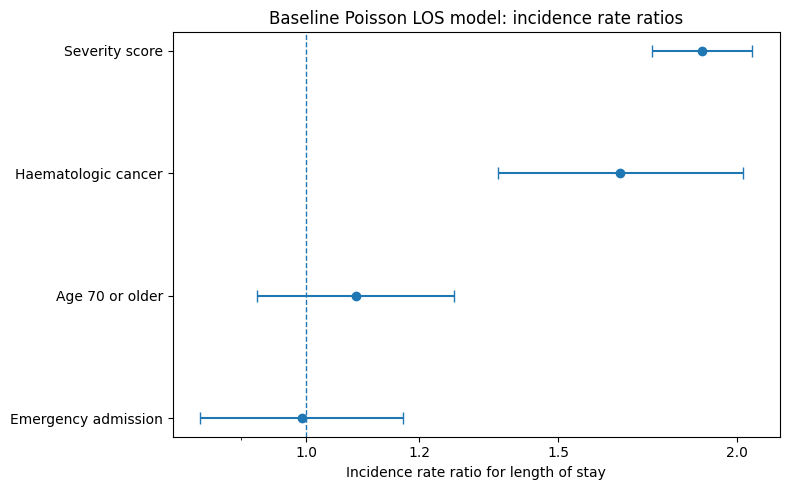

Saved: /Users/marissa/Desktop/portfolio/oncology-health-economics-portfolio/project_01_sparcs_cancer_utilisation_cost/outputs/figures/notebook_05_los_poisson_model_incidence_rate_ratios.png


In [10]:
# Figure: baseline Poisson LOS model incidence rate ratios
# Retained as a diagnostic baseline because the Poisson model showed overdispersion.

if los_model_status == "success":
    plot_ratio_model(
        los_poisson_table,
        ratio_col="incidence_rate_ratio",
        lower_col="incidence_rate_ratio_ci_lower",
        upper_col="incidence_rate_ratio_ci_upper",
        title="Baseline Poisson LOS model: incidence rate ratios",
        xlabel="Incidence rate ratio for length of stay",
        filename="notebook_05_los_poisson_model_incidence_rate_ratios.png",
        log_scale=True,
        tick_values=[0.8, 1.0, 1.2, 1.5, 2.0]
    )


## 7. Model 2: Length of stay final model, Negative Binomial GLM

Because the Poisson LOS model showed overdispersion, a Negative Binomial model is added for the final LOS interpretation.

The Negative Binomial model is better suited to overdispersed count-like outcomes because it allows the variance to exceed the mean. The model is still interpreted using incidence rate ratios.


In [11]:
# Negative Binomial model for length of stay
# This is the preferred LOS model when Poisson overdispersion is present.

los_nb_status = "success"

try:
    X_los_nb = add_constant_and_fit_columns(modelling_df, main_covariates)
    y_los_nb = modelling_df["length_of_stay_clean"]

    los_negative_binomial_model = sm.GLM(
        y_los_nb,
        X_los_nb,
        family=sm.families.NegativeBinomial()
    ).fit(cov_type="HC3")

    los_negative_binomial_table = make_model_table(
        los_negative_binomial_model,
        model_name="Negative Binomial GLM for length of stay",
        effect_type="incidence_rate_ratio",
        exponentiate=True
    )

    los_negative_binomial_table.to_csv(
        outputs_tables / "notebook_05_los_negative_binomial_model_results.csv",
        index=False
    )

    print(los_negative_binomial_model.summary())
    display(los_negative_binomial_table)

except Exception as e:
    los_nb_status = "failed"
    los_negative_binomial_table = write_model_failure("Negative Binomial GLM for length of stay", e)
    los_negative_binomial_table.to_csv(
        outputs_tables / "notebook_05_los_negative_binomial_model_results.csv",
        index=False
    )
    display(los_negative_binomial_table)


                  Generalized Linear Model Regression Results                   
Dep. Variable:     length_of_stay_clean   No. Observations:                 1218
Model:                              GLM   Df Residuals:                     1213
Model Family:          NegativeBinomial   Df Model:                            4
Link Function:                      Log   Scale:                          1.0000
Method:                            IRLS   Log-Likelihood:                -3517.3
Date:                  Sat, 16 May 2026   Deviance:                       752.96
Time:                          13:31:18   Pearson chi2:                 1.59e+03
No. Iterations:                       7   Pseudo R-squ. (CS):             0.2981
Covariance Type:                    HC3                                         
                                 coef    std err          z      P>|z|      [0.025      0.975]
----------------------------------------------------------------------------------------------


,model_name,term,coefficient,std_error,ci_lower,ci_upper,p_value,incidence_rate_ratio,incidence_rate_ratio_ci_lower,incidence_rate_ratio_ci_upper
0,Negative Binomial GLM for length of stay,const,0.1878,0.1023,-0.0128,0.3884,0.0665,1.2066,0.9873,1.4746
1,Negative Binomial GLM for length of stay,severity_score,0.6390,0.0429,0.5548,0.7231,0.0000,1.8945,1.7416,2.0609
2,Negative Binomial GLM for length of stay,is_emergency_admission_int,0.0058,0.0749,-0.1411,0.1526,0.9385,1.0058,0.8684,1.1649
3,Negative Binomial GLM for length of stay,older_adult_70plus,0.1239,0.0760,-0.0250,0.2729,0.1029,1.1319,0.9753,1.3137
4,Negative Binomial GLM for length of stay,haematologic_cancer,0.5186,0.0934,0.3355,0.7017,0.0000,1.6797,1.3986,2.0172


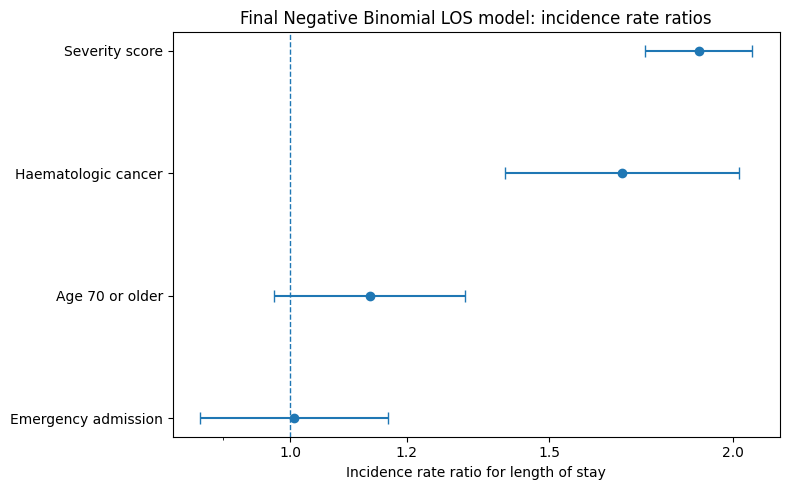

Saved: /Users/marissa/Desktop/portfolio/oncology-health-economics-portfolio/project_01_sparcs_cancer_utilisation_cost/outputs/figures/notebook_05_los_negative_binomial_model_incidence_rate_ratios.png


In [12]:
# Figure: final Negative Binomial LOS model incidence rate ratios
# This is the main final LOS model figure.

if los_nb_status == "success":
    plot_ratio_model(
        los_negative_binomial_table,
        ratio_col="incidence_rate_ratio",
        lower_col="incidence_rate_ratio_ci_lower",
        upper_col="incidence_rate_ratio_ci_upper",
        title="Final Negative Binomial LOS model: incidence rate ratios",
        xlabel="Incidence rate ratio for length of stay",
        filename="notebook_05_los_negative_binomial_model_incidence_rate_ratios.png",
        log_scale=True,
        tick_values=[0.8, 1.0, 1.2, 1.5, 2.0]
    )


## 8. Model 3: Total cost using log-linear regression

Total costs are right-skewed. A log-linear OLS model is used as a simple and interpretable prototype. Coefficients are exponentiated and interpreted as cost ratios.

This model is not presented as final causal inference. It tests the modelling workflow and shows how adjusted cost estimates will be generated after scaling up.


In [13]:
cost_ols_status = "success"

try:
    X_cost = add_constant_and_fit_columns(modelling_df, main_covariates)
    y_log_cost = modelling_df["log_total_costs_clean"]

    cost_log_ols_model = sm.OLS(
        y_log_cost,
        X_cost
    ).fit(cov_type="HC3")

    cost_log_ols_table = make_model_table(
        cost_log_ols_model,
        model_name="Log-linear OLS for total costs",
        effect_type="cost_ratio",
        exponentiate=True
    )

    cost_log_ols_table["percent_change_in_costs"] = (
        (cost_log_ols_table["cost_ratio"] - 1) * 100
    ).round(1)

    cost_log_ols_table.to_csv(
        outputs_tables / "notebook_05_cost_log_ols_model_results.csv",
        index=False
    )

    print(cost_log_ols_model.summary())
    display(cost_log_ols_table)

except Exception as e:
    cost_ols_status = "failed"
    cost_log_ols_table = write_model_failure("Log-linear OLS for total costs", e)
    cost_log_ols_table.to_csv(
        outputs_tables / "notebook_05_cost_log_ols_model_results.csv",
        index=False
    )
    display(cost_log_ols_table)


                              OLS Regression Results                             
Dep. Variable:     log_total_costs_clean   R-squared:                       0.200
Model:                               OLS   Adj. R-squared:                  0.198
Method:                    Least Squares   F-statistic:                     59.77
Date:                   Sat, 16 May 2026   Prob (F-statistic):           4.14e-46
Time:                           13:31:19   Log-Likelihood:                -1389.5
No. Observations:                   1218   AIC:                             2789.
Df Residuals:                       1213   BIC:                             2814.
Df Model:                              4                                         
Covariance Type:                     HC3                                         
                                 coef    std err          z      P>|z|      [0.025      0.975]
-------------------------------------------------------------------------------------

,model_name,term,coefficient,std_error,ci_lower,ci_upper,p_value,cost_ratio,cost_ratio_ci_lower,cost_ratio_ci_upper,percent_change_in_costs
0,Log-linear OLS for total costs,const,9.3837,0.0591,9.2678,9.4996,0.0000,11892.5768,10591.1880,13353.8733,1189157.7
1,Log-linear OLS for total costs,severity_score,0.4299,0.0306,0.3699,0.4899,0.0000,1.5372,1.4477,1.6322,53.7
2,Log-linear OLS for total costs,is_emergency_admission_int,-0.3968,0.0564,-0.5073,-0.2863,0.0000,0.6724,0.6021,0.7510,-32.8
3,Log-linear OLS for total costs,older_adult_70plus,-0.0682,0.0448,-0.1560,0.0196,0.1279,0.9341,0.8556,1.0198,-6.6
4,Log-linear OLS for total costs,haematologic_cancer,0.4023,0.0864,0.2329,0.5716,0.0000,1.4952,1.2622,1.7712,49.5


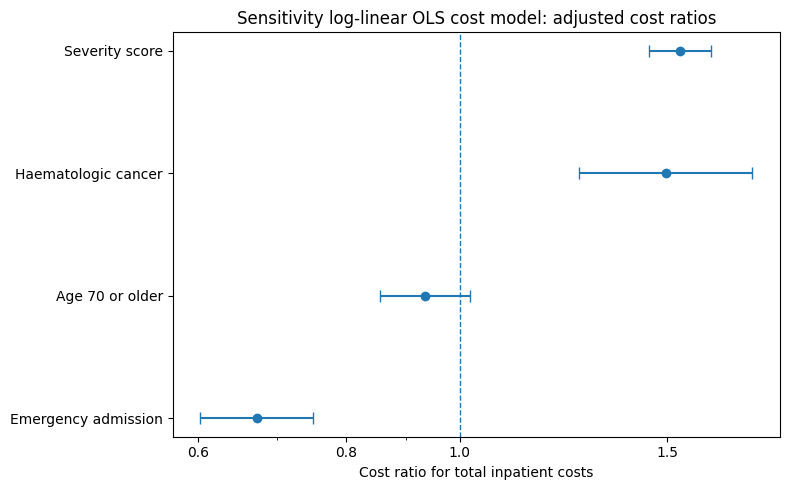

Saved: /Users/marissa/Desktop/portfolio/oncology-health-economics-portfolio/project_01_sparcs_cancer_utilisation_cost/outputs/figures/notebook_05_cost_log_ols_model_cost_ratios.png


In [14]:
# Figure: sensitivity log-linear OLS cost model cost ratios
# Retained as a sensitivity output. The Gamma GLM figure is the main final cost figure.

if cost_ols_status == "success":
    plot_ratio_model(
        cost_log_ols_table,
        ratio_col="cost_ratio",
        lower_col="cost_ratio_ci_lower",
        upper_col="cost_ratio_ci_upper",
        title="Sensitivity log-linear OLS cost model: adjusted cost ratios",
        xlabel="Cost ratio for total inpatient costs",
        filename="notebook_05_cost_log_ols_model_cost_ratios.png",
        log_scale=True,
        tick_values=[0.5, 0.6, 0.8, 1.0, 1.5, 2.0]
    )


## 9. Model 4: Total cost using Gamma GLM with log link

A Gamma GLM with log link is a common option for positive, right-skewed cost outcomes. This is included as a model workflow comparison against the simpler log-linear OLS model.


In [15]:
gamma_status = "success"

try:
    X_gamma = add_constant_and_fit_columns(modelling_df, main_covariates)
    y_cost = modelling_df["total_costs_clean"]

    cost_gamma_model = sm.GLM(
        y_cost,
        X_gamma,
        family=sm.families.Gamma(link=sm.families.links.Log())
    ).fit(cov_type="HC3")

    cost_gamma_table = make_model_table(
        cost_gamma_model,
        model_name="Gamma GLM with log link for total costs",
        effect_type="cost_ratio",
        exponentiate=True
    )

    cost_gamma_table["percent_change_in_costs"] = (
        (cost_gamma_table["cost_ratio"] - 1) * 100
    ).round(1)

    cost_gamma_table.to_csv(
        outputs_tables / "notebook_05_cost_gamma_model_results.csv",
        index=False
    )

    print(cost_gamma_model.summary())
    display(cost_gamma_table)

except Exception as e:
    gamma_status = "failed"
    cost_gamma_table = write_model_failure("Gamma GLM with log link for total costs", e)
    cost_gamma_table.to_csv(
        outputs_tables / "notebook_05_cost_gamma_model_results.csv",
        index=False
    )
    display(cost_gamma_table)


                 Generalized Linear Model Regression Results                  
Dep. Variable:      total_costs_clean   No. Observations:                 1218
Model:                            GLM   Df Residuals:                     1213
Model Family:                   Gamma   Df Model:                            4
Link Function:                    Log   Scale:                         0.68070
Method:                          IRLS   Log-Likelihood:                -13919.
Date:                Sat, 16 May 2026   Deviance:                       654.45
Time:                        13:31:19   Pearson chi2:                     826.
No. Iterations:                    15   Pseudo R-squ. (CS):             0.3031
Covariance Type:                  HC3                                         
                                 coef    std err          z      P>|z|      [0.025      0.975]
----------------------------------------------------------------------------------------------
const               

,model_name,term,coefficient,std_error,ci_lower,ci_upper,p_value,cost_ratio,cost_ratio_ci_lower,cost_ratio_ci_upper,percent_change_in_costs
0,Gamma GLM with log link for total costs,const,9.4541,0.0626,9.3313,9.5769,0.0000,12760.7046,11286.3493,14427.6574,1275970.5
1,Gamma GLM with log link for total costs,severity_score,0.5021,0.0301,0.4431,0.5612,0.0000,1.6523,1.5575,1.7528,65.2
2,Gamma GLM with log link for total costs,is_emergency_admission_int,-0.2963,0.0575,-0.4090,-0.1836,0.0000,0.7436,0.6643,0.8323,-25.6
3,Gamma GLM with log link for total costs,older_adult_70plus,-0.1325,0.0471,-0.2247,-0.0402,0.0049,0.8759,0.7988,0.9606,-12.4
4,Gamma GLM with log link for total costs,haematologic_cancer,0.5190,0.0994,0.3242,0.7139,0.0000,1.6804,1.3829,2.0419,68.0


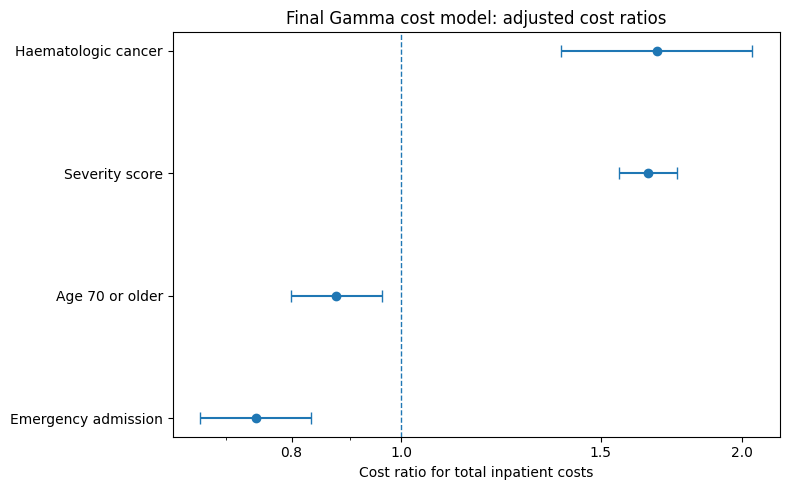

Saved: /Users/marissa/Desktop/portfolio/oncology-health-economics-portfolio/project_01_sparcs_cancer_utilisation_cost/outputs/figures/notebook_05_cost_gamma_model_cost_ratios.png


In [16]:
# Figure: final Gamma cost model cost ratios
# This is the main final cost model figure.

if gamma_status == "success":
    plot_ratio_model(
        cost_gamma_table,
        ratio_col="cost_ratio",
        lower_col="cost_ratio_ci_lower",
        upper_col="cost_ratio_ci_upper",
        title="Final Gamma cost model: adjusted cost ratios",
        xlabel="Cost ratio for total inpatient costs",
        filename="notebook_05_cost_gamma_model_cost_ratios.png",
        log_scale=True,
        tick_values=[0.5, 0.6, 0.8, 1.0, 1.5, 2.0]
    )


## 10. Model 5: High-cost admission indicator

A high-cost admission is defined as total cost above the 75th percentile in the primary cancer cohort. This model is included as a simple classification-style health services analysis.

Because the development sample is small and there are limited high-cost events, this model is deliberately more parsimonious than the continuous cost models.


In [17]:
high_cost_covariates = [
    "severity_score",
    "is_emergency_admission_int",
    "haematologic_cancer"
]

high_cost_status = "success"

try:
    X_high_cost = add_constant_and_fit_columns(modelling_df, high_cost_covariates)
    y_high_cost = modelling_df["is_high_cost"]

    high_cost_logistic_model = sm.GLM(
        y_high_cost,
        X_high_cost,
        family=sm.families.Binomial()
    ).fit(cov_type="HC3")

    high_cost_logistic_table = make_model_table(
        high_cost_logistic_model,
        model_name="Logistic model for high-cost admission",
        effect_type="odds_ratio",
        exponentiate=True
    )

    high_cost_logistic_table.to_csv(
        outputs_tables / "notebook_05_high_cost_logistic_model_results.csv",
        index=False
    )

    print(high_cost_logistic_model.summary())
    display(high_cost_logistic_table)

except Exception as e:
    high_cost_status = "failed"
    high_cost_logistic_table = write_model_failure("Logistic model for high-cost admission", e)
    high_cost_logistic_table.to_csv(
        outputs_tables / "notebook_05_high_cost_logistic_model_results.csv",
        index=False
    )
    display(high_cost_logistic_table)


                 Generalized Linear Model Regression Results                  
Dep. Variable:           is_high_cost   No. Observations:                 1218
Model:                            GLM   Df Residuals:                     1214
Model Family:                Binomial   Df Model:                            3
Link Function:                  Logit   Scale:                          1.0000
Method:                          IRLS   Log-Likelihood:                -556.95
Date:                Sat, 16 May 2026   Deviance:                       1113.9
Time:                        13:31:19   Pearson chi2:                 1.20e+03
No. Iterations:                     5   Pseudo R-squ. (CS):             0.1903
Covariance Type:                  HC3                                         
                                 coef    std err          z      P>|z|      [0.025      0.975]
----------------------------------------------------------------------------------------------
const               

,model_name,term,coefficient,std_error,ci_lower,ci_upper,p_value,odds_ratio,odds_ratio_ci_lower,odds_ratio_ci_upper
0,Logistic model for high-cost admission,const,-4.4361,0.2789,-4.9828,-3.8895,0.0000,0.0118,0.0069,0.0205
1,Logistic model for high-cost admission,severity_score,1.3323,0.1090,1.1187,1.5460,0.0000,3.7899,3.0609,4.6926
2,Logistic model for high-cost admission,is_emergency_admission_int,-0.4989,0.1706,-0.8334,-0.1644,0.0035,0.6072,0.4346,0.8484
3,Logistic model for high-cost admission,haematologic_cancer,1.0719,0.2075,0.6651,1.4786,0.0000,2.9209,1.9448,4.3869


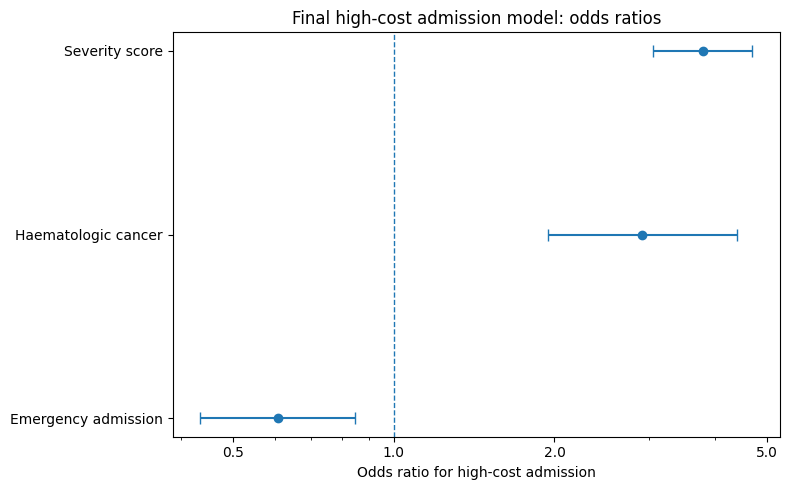

Saved: /Users/marissa/Desktop/portfolio/oncology-health-economics-portfolio/project_01_sparcs_cancer_utilisation_cost/outputs/figures/notebook_05_high_cost_model_odds_ratios.png


In [18]:
# Figure: final high-cost admission model odds ratios
# This is the main final high-cost admission model figure.

if high_cost_status == "success":
    plot_ratio_model(
        high_cost_logistic_table,
        ratio_col="odds_ratio",
        lower_col="odds_ratio_ci_lower",
        upper_col="odds_ratio_ci_upper",
        title="Final high-cost admission model: odds ratios",
        xlabel="Odds ratio for high-cost admission",
        filename="notebook_05_high_cost_model_odds_ratios.png",
        log_scale=True,
        tick_values=[0.3, 0.5, 1.0, 2.0, 5.0, 10.0]
    )


## 11. Diagnostic check: observed versus predicted costs

This figure is retained as a diagnostic output only. It should not be used as a main report figure because extreme high-cost admissions dominate the visual scale.

The main final cost model figure is the Gamma GLM cost-ratio plot.


,metric,value
0,Observed median total costs,27048.66
1,Predicted median total costs,28100.75
2,Observed mean total costs,41849.43
3,Predicted mean total costs,30533.58


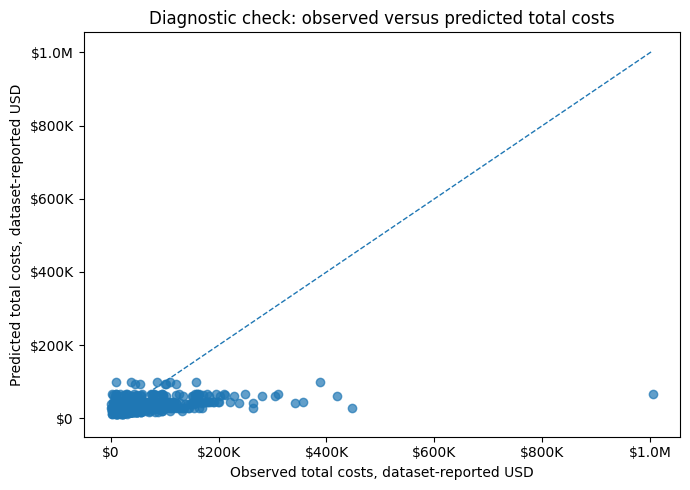

Saved: /Users/marissa/Desktop/portfolio/oncology-health-economics-portfolio/project_01_sparcs_cancer_utilisation_cost/outputs/figures/notebook_05_observed_vs_predicted_costs.png


In [19]:
if cost_ols_status == "success":
    modelling_df["predicted_log_total_costs_ols"] = cost_log_ols_model.predict(X_cost)
    modelling_df["predicted_total_costs_ols"] = np.exp(modelling_df["predicted_log_total_costs_ols"])

    prediction_summary = pd.DataFrame({
        "metric": [
            "Observed median total costs",
            "Predicted median total costs",
            "Observed mean total costs",
            "Predicted mean total costs"
        ],
        "value": [
            round(modelling_df["total_costs_clean"].median(), 2),
            round(modelling_df["predicted_total_costs_ols"].median(), 2),
            round(modelling_df["total_costs_clean"].mean(), 2),
            round(modelling_df["predicted_total_costs_ols"].mean(), 2)
        ]
    })

    prediction_summary.to_csv(
        outputs_tables / "notebook_05_cost_model_prediction_summary.csv",
        index=False
    )

    display(prediction_summary)

    fig, ax = plt.subplots(figsize=(7, 5))
    ax.scatter(modelling_df["total_costs_clean"], modelling_df["predicted_total_costs_ols"], alpha=0.7)
    max_val = max(
        modelling_df["total_costs_clean"].max(),
        modelling_df["predicted_total_costs_ols"].max()
    )
    ax.plot([0, max_val], [0, max_val], linestyle="--", linewidth=1)
    ax.set_xlabel("Observed total costs, dataset-reported USD")
    ax.set_ylabel("Predicted total costs, dataset-reported USD")
    ax.set_title("Diagnostic check: observed versus predicted total costs")
    ax.xaxis.set_major_formatter(FuncFormatter(money_formatter))
    ax.yaxis.set_major_formatter(FuncFormatter(money_formatter))
    plt.tight_layout()
    save_current_figure("notebook_05_observed_vs_predicted_costs.png")
else:
    prediction_summary = pd.DataFrame({
        "metric": ["cost_prediction_status"],
        "value": ["Cost OLS model failed; no prediction summary available."]
    })
    prediction_summary.to_csv(
        outputs_tables / "notebook_05_cost_model_prediction_summary.csv",
        index=False
    )
    display(prediction_summary)


## 12. Model comparison summary

This table summarises which models ran successfully and how they should be interpreted.


In [20]:
# Choose final LOS model based on Poisson overdispersion.

try:
    dispersion_value = float(
        los_diagnostic_summary.loc[
            los_diagnostic_summary["diagnostic"].eq("dispersion_ratio"),
            "value"
        ].iloc[0]
    )
except Exception:
    dispersion_value = np.nan

preferred_los_model = (
    "Negative Binomial GLM for length of stay"
    if los_nb_status == "success" and (pd.isna(dispersion_value) or dispersion_value > 1.5)
    else "Poisson GLM for length of stay"
)

model_comparison_summary = pd.DataFrame({
    "model": [
        "Poisson GLM for length of stay",
        "Negative Binomial GLM for length of stay",
        "Log-linear OLS for total costs",
        "Gamma GLM with log link for total costs",
        "Logistic model for high-cost admission"
    ],
    "outcome": [
        "Length of stay",
        "Length of stay",
        "Log total costs",
        "Total costs",
        "High-cost admission indicator"
    ],
    "effect_measure": [
        "Incidence rate ratio",
        "Incidence rate ratio",
        "Cost ratio / percent change",
        "Cost ratio / percent change",
        "Odds ratio"
    ],
    "status": [
        los_model_status,
        los_nb_status,
        cost_ols_status,
        gamma_status,
        high_cost_status
    ],
    "final_interpretation_role": [
        "Baseline only if overdispersed",
        "Preferred LOS model if Poisson overdispersed",
        "Sensitivity cost model",
        "Main final cost model",
        "Main final high-cost model"
    ],
    "interpretation_status": [
        "Diagnostic baseline" if preferred_los_model != "Poisson GLM for length of stay" else "Main LOS model",
        "Main LOS model" if preferred_los_model == "Negative Binomial GLM for length of stay" else "Sensitivity model",
        "Final with diagnostics" if analysis_mode != "prototype" else "Prototype only",
        "Final with diagnostics" if analysis_mode != "prototype" else "Prototype only",
        "Final with diagnostics" if analysis_mode != "prototype" else "Prototype only"
    ]
})

model_comparison_summary.to_csv(
    outputs_tables / "notebook_05_model_comparison_summary.csv",
    index=False
)

display(model_comparison_summary)


,model,outcome,effect_measure,status,final_interpretation_role,interpretation_status
0,Poisson GLM for length of stay,Length of stay,Incidence rate ratio,success,Baseline only if overdispersed,Diagnostic baseline
1,Negative Binomial GLM for length of stay,Length of stay,Incidence rate ratio,success,Preferred LOS model if Poisson overdispersed,Main LOS model
2,Log-linear OLS for total costs,Log total costs,Cost ratio / percent change,success,Sensitivity cost model,Final with diagnostics
3,Gamma GLM with log link for total costs,Total costs,Cost ratio / percent change,success,Main final cost model,Final with diagnostics
4,Logistic model for high-cost admission,High-cost admission indicator,Odds ratio,success,Main final high-cost model,Final with diagnostics


## 13. Report-facing model tables

The raw model tables retain the intercept for reproducibility, but report-facing tables exclude the intercept because exponentiated intercepts are not useful for interpretation in this portfolio.

These tables should still be interpreted as **prototype outputs** while the dataset remains a 5,000-row development sample.


In [21]:
report_model_tables = []

if los_model_status == "success":
    los_report_table = los_poisson_table[los_poisson_table["term"] != "const"].copy()
    los_report_table["term_label"] = los_report_table["term"].map(term_label_map).fillna(los_report_table["term"])
    los_report_table.to_csv(
        outputs_tables / "notebook_05_los_poisson_model_results_report_facing.csv",
        index=False
    )
    report_model_tables.append(los_report_table)

if los_nb_status == "success":
    los_nb_report_table = los_negative_binomial_table[los_negative_binomial_table["term"] != "const"].copy()
    los_nb_report_table["term_label"] = los_nb_report_table["term"].map(term_label_map).fillna(los_nb_report_table["term"])
    los_nb_report_table.to_csv(
        outputs_tables / "notebook_05_los_negative_binomial_model_results_report_facing.csv",
        index=False
    )
    report_model_tables.append(los_nb_report_table)

if cost_ols_status == "success":
    cost_ols_report_table = cost_log_ols_table[cost_log_ols_table["term"] != "const"].copy()
    cost_ols_report_table["term_label"] = cost_ols_report_table["term"].map(term_label_map).fillna(cost_ols_report_table["term"])
    cost_ols_report_table.to_csv(
        outputs_tables / "notebook_05_cost_log_ols_model_results_report_facing.csv",
        index=False
    )
    report_model_tables.append(cost_ols_report_table)

if gamma_status == "success":
    gamma_report_table = cost_gamma_table[cost_gamma_table["term"] != "const"].copy()
    gamma_report_table["term_label"] = gamma_report_table["term"].map(term_label_map).fillna(gamma_report_table["term"])
    gamma_report_table.to_csv(
        outputs_tables / "notebook_05_cost_gamma_model_results_report_facing.csv",
        index=False
    )
    report_model_tables.append(gamma_report_table)

if high_cost_status == "success":
    high_cost_report_table = high_cost_logistic_table[high_cost_logistic_table["term"] != "const"].copy()
    high_cost_report_table["term_label"] = high_cost_report_table["term"].map(term_label_map).fillna(high_cost_report_table["term"])
    high_cost_report_table.to_csv(
        outputs_tables / "notebook_05_high_cost_logistic_model_results_report_facing.csv",
        index=False
    )
    report_model_tables.append(high_cost_report_table)

print("Saved report-facing model tables excluding intercept rows.")


Saved report-facing model tables excluding intercept rows.


## 14. Compact report summary

The report summary focuses on workflow readiness and only reports model findings carefully. If the dataset is a development sample, the phrasing should remain cautious.


In [22]:
def extract_effect(table, term, effect_col, lower_col, upper_col):
    if table is None or "term" not in table.columns:
        return "Not available"
    row = table[table["term"].eq(term)]
    if row.empty:
        return "Not available"
    row = row.iloc[0]
    return f"{row[effect_col]:.2f} ({row[lower_col]:.2f} to {row[upper_col]:.2f})"

# Main LOS model should be Negative Binomial when the Poisson model is overdispersed.
if "preferred_los_model" not in globals():
    preferred_los_model = "Negative Binomial GLM for length of stay" if los_nb_status == "success" else "Poisson GLM for length of stay"

if preferred_los_model == "Negative Binomial GLM for length of stay" and los_nb_status == "success":
    los_main_table = los_negative_binomial_table
    los_model_label = "Negative Binomial LOS model"
else:
    los_main_table = los_poisson_table
    los_model_label = "Poisson LOS model"

los_severity_effect = (
    extract_effect(
        los_main_table,
        "severity_score",
        "incidence_rate_ratio",
        "incidence_rate_ratio_ci_lower",
        "incidence_rate_ratio_ci_upper"
    )
    if (los_nb_status == "success" or los_model_status == "success") else "Model failed"
)

cost_severity_effect = (
    extract_effect(
        cost_gamma_table if gamma_status == "success" else cost_log_ols_table,
        "severity_score",
        "cost_ratio",
        "cost_ratio_ci_lower",
        "cost_ratio_ci_upper"
    )
    if (gamma_status == "success" or cost_ols_status == "success") else "Model failed"
)

high_cost_severity_effect = (
    extract_effect(
        high_cost_logistic_table,
        "severity_score",
        "odds_ratio",
        "odds_ratio_ci_lower",
        "odds_ratio_ci_upper"
    )
    if high_cost_status == "success" else "Model failed"
)

report_summary = pd.DataFrame({
    "finding": [
        "Model input rows",
        "Analysis mode",
        "Preferred LOS model",
        "Primary modelling update",
        f"{los_model_label} severity effect, IRR with 95% CI",
        "Main cost model severity effect, cost ratio with 95% CI",
        "High-cost model severity effect, OR with 95% CI",
        "Recommended final modelling action"
    ],
    "value": [
        len(modelling_df),
        analysis_mode,
        preferred_los_model,
        (
            "Poisson LOS model showed overdispersion; Negative Binomial is used for final LOS interpretation."
            if preferred_los_model == "Negative Binomial GLM for length of stay"
            else "Poisson LOS model retained as main LOS model because overdispersion was not flagged."
        ),
        los_severity_effect,
        cost_severity_effect,
        high_cost_severity_effect,
        "Use Negative Binomial LOS model, Gamma cost model and logistic high-cost model in the final report."
    ]
})

report_summary.to_csv(
    outputs_tables / "notebook_05_report_summary.csv",
    index=False
)

display(report_summary)


,finding,value
0,Model input rows,1218
1,Analysis mode,final_analysis_ready
2,Preferred LOS model,Negative Binomial GLM for length of stay
3,Primary modelling update,Poisson LOS model showed overdispersion; Negat...
4,"Negative Binomial LOS model severity effect, I...",1.89 (1.74 to 2.06)
5,"Main cost model severity effect, cost ratio wi...",1.65 (1.56 to 1.75)
6,"High-cost model severity effect, OR with 95% CI",3.79 (3.06 to 4.69)
7,Recommended final modelling action,"Use Negative Binomial LOS model, Gamma cost mo..."


## 15. Final output checklist


### Processed data

- `data/processed/sparcs_2024_modelling_dataset_prototype.csv`

### Tables

- `outputs/tables/notebook_05_modelling_readiness.csv`
- `outputs/tables/notebook_05_model_dataset_summary.csv`
- `outputs/tables/notebook_05_covariate_summary.csv`
- `outputs/tables/notebook_05_los_poisson_model_results.csv`
- `outputs/tables/notebook_05_los_model_diagnostics.csv`
- `outputs/tables/notebook_05_los_negative_binomial_model_results.csv`
- `outputs/tables/notebook_05_cost_log_ols_model_results.csv`
- `outputs/tables/notebook_05_cost_gamma_model_results.csv`
- `outputs/tables/notebook_05_high_cost_logistic_model_results.csv`
- `outputs/tables/notebook_05_cost_model_prediction_summary.csv`
- `outputs/tables/notebook_05_model_comparison_summary.csv`
- `outputs/tables/notebook_05_report_summary.csv`

### Report-facing model tables

- `outputs/tables/notebook_05_los_negative_binomial_model_results_report_facing.csv`
- `outputs/tables/notebook_05_cost_gamma_model_results_report_facing.csv`
- `outputs/tables/notebook_05_high_cost_logistic_model_results_report_facing.csv`

### Main final report figures

- `outputs/figures/notebook_05_los_negative_binomial_model_incidence_rate_ratios.png`
- `outputs/figures/notebook_05_cost_gamma_model_cost_ratios.png`
- `outputs/figures/notebook_05_high_cost_model_odds_ratios.png`

### Diagnostic or sensitivity figures

- `outputs/figures/notebook_05_los_poisson_model_incidence_rate_ratios.png`
- `outputs/figures/notebook_05_cost_log_ols_model_cost_ratios.png`
- `outputs/figures/notebook_05_observed_vs_predicted_costs.png`

## Interpretation note

Use the Negative Binomial LOS model, Gamma cost model and logistic high-cost admission model as the final modelling results. Treat the Poisson LOS model, log-linear OLS cost model and observed-versus-predicted plot as diagnostics or sensitivity outputs.
